# 03 — Task-Level Predictive Models

The occupation-level model achieved R^2 ~ 0. Can we do better at the **task level**?

With 3,259 tasks (10x more observations) and continuous outcome variables,
standard ML models should find real signal. This notebook trains and evaluates
task-level models to predict AI autonomy and understand what drives automation.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data import build_task_feature_matrix, build_task_feature_matrix_api
from src.features import build_feature_matrix, compute_platform_gap
from src.model import (
    train_task_autonomy_models, train_time_savings_models,
    train_velocity_models, FEATURE_COLS,
)

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 150
C = {'auto': '#E63946', 'aug': '#457B9D', 'accent': '#F4A261', 'teal': '#2A9D8F'}

In [2]:
tasks = build_task_feature_matrix()
tasks_unique = tasks.drop_duplicates(subset='task_name').reset_index(drop=True)
print(f"Task-level modeling: {len(tasks_unique):,} unique tasks")

Task-level modeling: 3,259 unique tasks


## Predicting AI autonomy at the task level

Target: AI autonomy score (1-5 scale). Features: education requirements,
time estimates, success rates, collaboration modes, human-only ability.

**Comparison:** Occupation-level velocity prediction achieved R^2 ~ 0.
Task-level autonomy prediction should do substantially better.

In [3]:
task_results = train_task_autonomy_models(tasks_unique)

print('Task-Level AI Autonomy — Regression Results')
print('=' * 55)
for r in task_results:
    print(f"\n{r.name}:")
    print(f"  R2 (train):  {r.metrics['r2_train']:.3f}")
    print(f"  R2 (5-fold): {r.metrics['r2_cv_mean']:.3f} +/- {r.metrics['r2_cv_std']:.3f}")
    print(f"  MAE:         {r.metrics['mae']:.4f}")

best_task = max(task_results, key=lambda r: r.metrics['r2_cv_mean'])

# Compare with occupation-level
occ_features = build_feature_matrix()
try:
    occ_results = train_velocity_models(occ_features)
    best_occ = max(occ_results, key=lambda r: r.metrics['r2_cv_mean'])
    print(f"\n{'='*55}")
    print(f"COMPARISON:")
    print(f"  Task-level R2 (CV):       {best_task.metrics['r2_cv_mean']:.3f}  <-- signal exists here")
    print(f"  Occupation-level R2 (CV): {best_occ.metrics['r2_cv_mean']:.3f}  <-- washed out by aggregation")
except Exception:
    pass

Task-Level AI Autonomy — Regression Results

XGBoost:
  R2 (train):  0.752
  R2 (5-fold): 0.279 +/- 0.065
  MAE:         0.1057

GradientBoosting:
  R2 (train):  0.657
  R2 (5-fold): 0.288 +/- 0.055
  MAE:         0.1259

COMPARISON:
  Task-level R2 (CV):       0.288  <-- signal exists here
  Occupation-level R2 (CV): -0.018  <-- washed out by aggregation


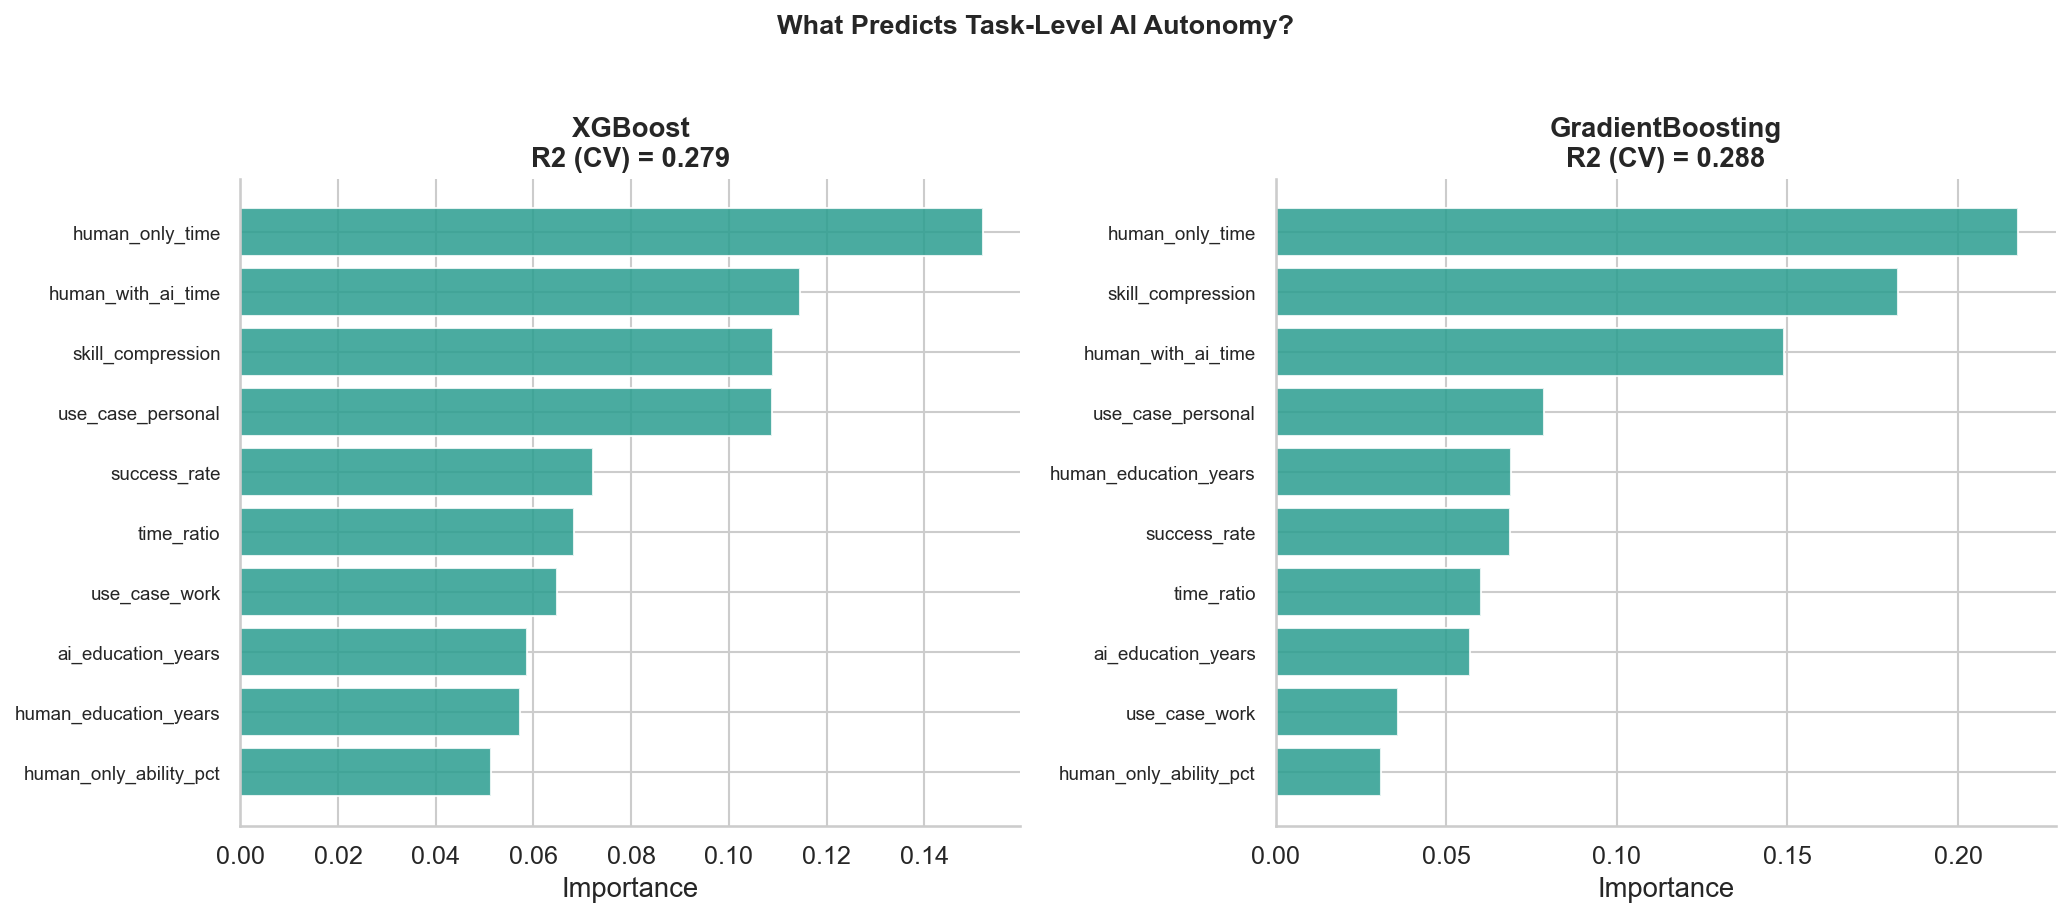

In [4]:
fig, axes = plt.subplots(1, len(task_results), figsize=(7 * len(task_results), 6))
if len(task_results) == 1:
    axes = [axes]

for ax, r in zip(axes, task_results):
    imp = r.feature_importance.head(10)
    ax.barh(range(len(imp)), imp['importance'], color=C['teal'], alpha=0.85)
    ax.set_yticks(range(len(imp)))
    ax.set_yticklabels(imp['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(f"{r.name}\nR2 (CV) = {r.metrics['r2_cv_mean']:.3f}", fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('What Predicts Task-Level AI Autonomy?',
             fontsize=13, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.savefig('../figures/08_task_autonomy_feature_importance.png', bbox_inches='tight')
plt.show()

## Key correlations at the task level

With 3,259 observations, even modest effect sizes are highly significant.

In [5]:
corr_pairs = [
    ('skill_compression', 'automation_share', 'Skill Compression'),
    ('skill_compression', 'ai_autonomy_mean', 'Skill Compression'),
    ('success_rate', 'automation_share', 'Task Success Rate'),
    ('human_only_time', 'ai_autonomy_mean', 'Human-Only Time'),
    ('human_only_ability_pct', 'ai_autonomy_mean', 'Human-Only Ability'),
    ('conversation_count', 'automation_share', 'Conversation Count'),
]

print(f"{'Feature':35s} {'Target':25s} {'r':>8s} {'p-value':>12s} {'n':>6s}")
print('-' * 90)
for x, y, label in corr_pairs:
    valid = tasks_unique[[x, y]].dropna()
    if len(valid) > 30:
        r, p = stats.pearsonr(valid[x], valid[y])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f"  {x:33s} {y:25s} {r:+.3f}   {p:.2e}  {len(valid):>5,} {sig}")

Feature                             Target                           r      p-value      n
------------------------------------------------------------------------------------------
  skill_compression                 automation_share          +0.209   1.84e-33  3,259 ***
  skill_compression                 ai_autonomy_mean          -0.209   2.03e-33  3,259 ***
  success_rate                      automation_share          -0.441   1.33e-130  2,739 ***
  human_only_time                   ai_autonomy_mean          +0.327   2.73e-82  3,259 ***
  human_only_ability_pct            ai_autonomy_mean          -0.210   3.44e-32  3,105 ***
  conversation_count                automation_share          +0.155   5.78e-19  3,259 ***


## Platform divergence at the task level

The same task can look very different on API vs. Claude.ai.
With 2,400+ matched tasks, we can measure this gap precisely.

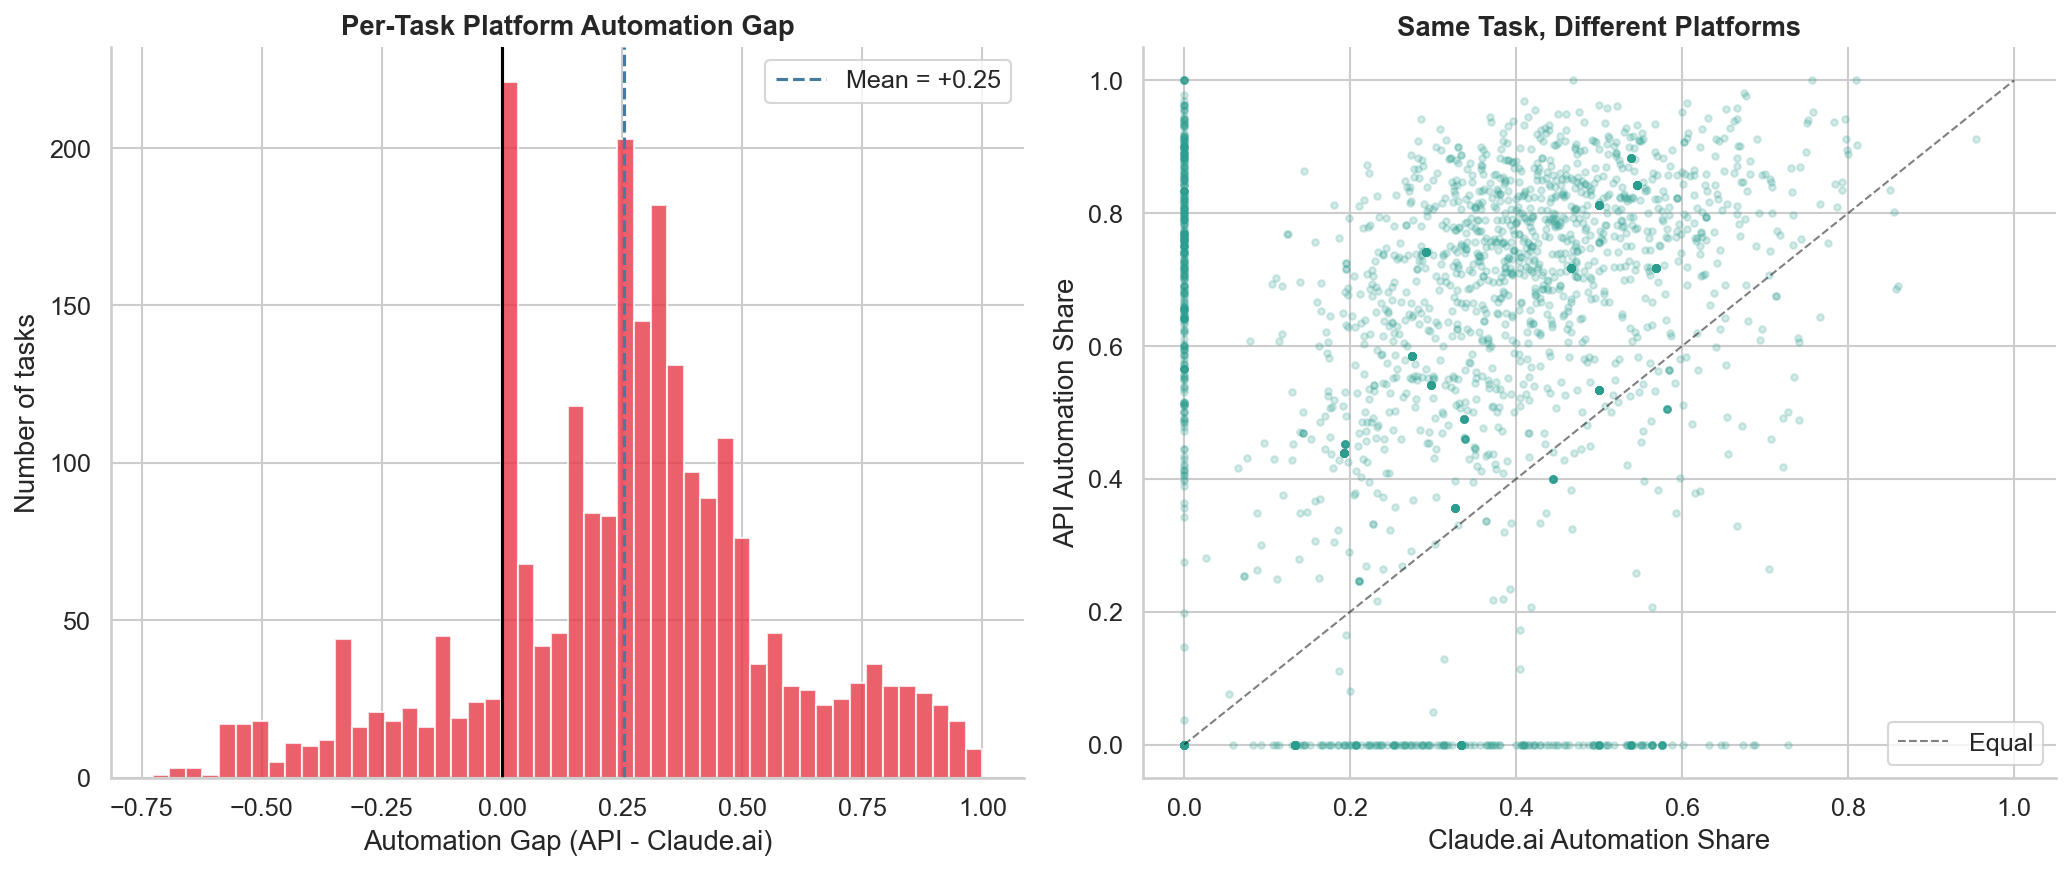

Tasks with higher API automation: 1902 (78%)
Mean automation gap: +0.254
Median automation gap: +0.275


In [6]:
gap = compute_platform_gap()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Automation gap distribution
ax = axes[0]
ax.hist(gap['automation_gap'], bins=50, color=C['auto'], alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=1.5)
ax.axvline(gap['automation_gap'].mean(), color=C['aug'], linestyle='--', linewidth=1.5,
           label=f"Mean = {gap['automation_gap'].mean():+.2f}")
ax.set_xlabel('Automation Gap (API - Claude.ai)')
ax.set_ylabel('Number of tasks')
ax.set_title('Per-Task Platform Automation Gap', fontweight='bold')
ax.legend()

# Scatter: Claude.ai vs API automation share
ax = axes[1]
ax.scatter(gap['automation_share'], gap['automation_share_api'],
           alpha=0.2, s=10, color=C['teal'])
lim = [0, 1]
ax.plot(lim, lim, '--', color='black', linewidth=1, alpha=0.5, label='Equal')
ax.set_xlabel('Claude.ai Automation Share')
ax.set_ylabel('API Automation Share')
ax.set_title('Same Task, Different Platforms', fontweight='bold')
ax.legend()

sns.despine()
plt.tight_layout()
plt.savefig('../figures/09_platform_divergence.png', bbox_inches='tight')
plt.show()

print(f"Tasks with higher API automation: {(gap['automation_gap'] > 0).sum()} ({(gap['automation_gap'] > 0).mean():.0%})")
print(f"Mean automation gap: {gap['automation_gap'].mean():+.3f}")
print(f"Median automation gap: {gap['automation_gap'].median():+.3f}")

## What predicts which tasks diverge most between platforms?

In [7]:
# Merge gap data with task features
gap_enriched = gap.merge(
    tasks_unique[['task_name', 'skill_compression', 'human_only_time',
                  'success_rate', 'human_only_ability_pct', 'human_education_years']],
    on='task_name', how='inner'
)

print(f"Tasks with both platform data and features: {len(gap_enriched):,}")
print()
print("Correlations with automation gap (API - Claude.ai):")
for col in ['skill_compression', 'human_only_time', 'success_rate',
            'human_only_ability_pct', 'human_education_years']:
    valid = gap_enriched[['automation_gap', col]].dropna()
    if len(valid) > 30:
        r, p = stats.pearsonr(valid['automation_gap'], valid[col])
        print(f"  {col:30s} r={r:+.3f}  p={p:.2e}")

Tasks with both platform data and features: 2,429

Correlations with automation gap (API - Claude.ai):
  skill_compression              r=-0.125  p=6.52e-10
  human_only_time                r=+0.041  p=4.35e-02
  success_rate                   r=-0.046  p=3.08e-02
  human_only_ability_pct         r=+0.049  p=1.66e-02
  human_education_years          r=+0.048  p=1.83e-02


## Task success and automation: a surprising relationship

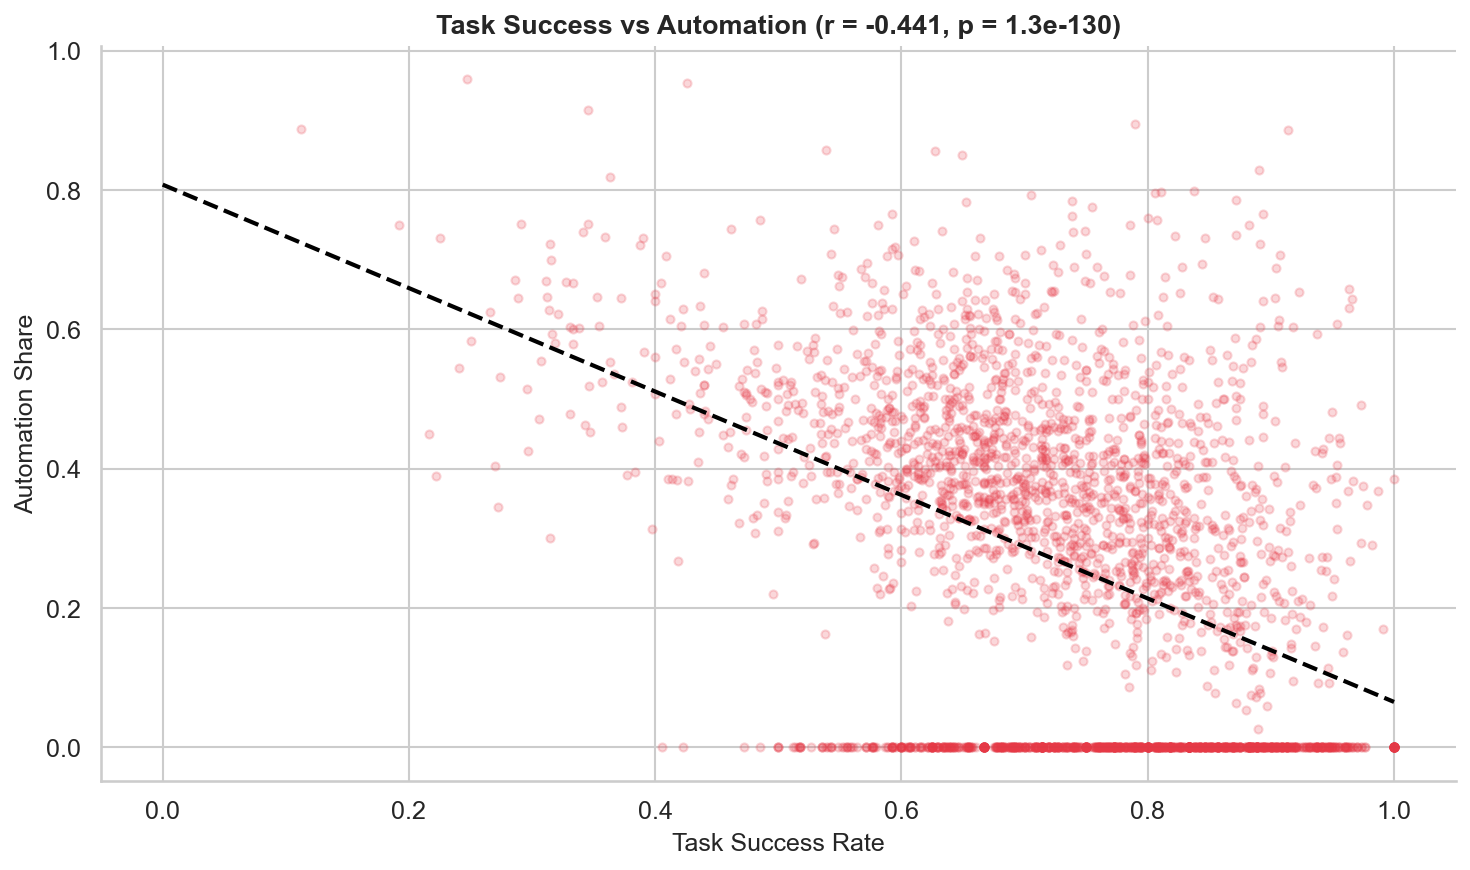

Strong negative correlation: tasks with LOWER success rates have HIGHER automation shares.
Interpretation: automated (directive) tasks involve less human oversight,
so success is harder to verify — or automated pipelines have higher error tolerance.


In [8]:
valid = tasks_unique.dropna(subset=['success_rate', 'automation_share']).copy()
r, p = stats.pearsonr(valid['success_rate'], valid['automation_share'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(valid['success_rate'], valid['automation_share'],
           alpha=0.2, s=15, color=C['auto'])

z = np.polyfit(valid['success_rate'], valid['automation_share'], 1)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, np.poly1d(z)(x_line), '--', color='black', linewidth=2)

ax.set_xlabel('Task Success Rate', fontsize=12)
ax.set_ylabel('Automation Share', fontsize=12)
ax.set_title(f'Task Success vs Automation (r = {r:.3f}, p = {p:.1e})',
             fontsize=13, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('../figures/10_success_vs_automation.png', bbox_inches='tight')
plt.show()

print(f"Strong negative correlation: tasks with LOWER success rates have HIGHER automation shares.")
print(f"Interpretation: automated (directive) tasks involve less human oversight,")
print(f"so success is harder to verify — or automated pipelines have higher error tolerance.")

---

**Key findings:**
1. **Task-level R^2 = 0.29** (CV) vs occupation-level R^2 ~ 0 — the signal lives at task granularity
2. **Time estimates and skill compression** are the strongest predictors of AI autonomy
3. **API automation is ~25pp higher** than Claude.ai for the same task across 2,400+ tasks
4. **Lower task success correlates with higher automation** — automated tasks have less human quality control

**Next:** [04_jagged_frontier.ipynb](04_jagged_frontier.ipynb)